# Problem 5.52 — Relativistic Doppler Effect: Radar Speed Gun

## Problem Statement

A highway patrol officer uses a device that measures the speed of vehicles by bouncing radar off them and measuring the Doppler shift. The **outgoing radar has a frequency of 100 GHz** and the **returning echo has a frequency 15.0 kHz higher**. What is the velocity of the vehicle?

---

## Background

The relativistic Doppler formula for a source and observer moving **toward** each other is:

$$f_{\text{obs}} = f_s \sqrt{\frac{1 + v/c}{1 - v/c}}$$

For a radar echo, the wave shifts **twice**:
1. The moving car receives the radar at a Doppler-shifted frequency $f_1$ (car is the "observer" moving toward the source)
2. The car reflects and re-emits at $f_1$, and the patrol officer (now the observer) receives it Doppler-shifted again

Both shifts are in the same direction, so the overall shift is:

$$f_{\text{echo}} = f_{\text{out}} \cdot \frac{1 + v/c}{1 - v/c}$$

---

## Given

| Quantity | Value |
|----------|-------|
| Outgoing frequency | $f_0 = 100$ GHz $= 1.00 \times 10^{11}$ Hz |
| Frequency increase | $\Delta f = 15.0$ kHz $= 1.50 \times 10^4$ Hz |
| Observed echo frequency | $f_{\text{echo}} = f_0 + \Delta f$ |

In [1]:
import math

# ── Given ─────────────────────────────────────────────────────────────
c      = 3.00e8           # speed of light, m/s
f0     = 100.0e9          # outgoing radar frequency, Hz (100 GHz)
delta_f = 15.0e3          # frequency shift in echo, Hz (15.0 kHz)

f_echo = f0 + delta_f     # observed echo frequency
print(f"Outgoing frequency:  f₀     = {f0:.6e} Hz")
print(f"Frequency shift:     Δf     = {delta_f:.6e} Hz")
print(f"Echo frequency:      f_echo = {f_echo:.6e} Hz")
print()

# ── Double-Doppler formula ─────────────────────────────────────────────
# f_echo = f0 * (1 + beta) / (1 - beta)   where beta = v/c
#
# Solve for beta:
#   f_echo / f0 = (1 + beta) / (1 - beta)
#   Let R = f_echo / f0
#   R(1 - beta) = 1 + beta
#   R - R*beta  = 1 + beta
#   R - 1       = beta + R*beta = beta(1 + R)
#   beta        = (R - 1) / (R + 1)

R = f_echo / f0
print(f"Frequency ratio  R = f_echo/f₀ = {R:.10f}")
print()

beta = (R - 1) / (R + 1)
v    = beta * c

print(f"Solving for β:")
print(f"  β = (R − 1)/(R + 1)")
print(f"  β = ({R:.10f} − 1) / ({R:.10f} + 1)")
print(f"  β = {R-1:.10e} / {R+1:.10f}")
print(f"  β = {beta:.10e}")
print()
print(f"Vehicle speed:  v = β × c")
print(f"              v = {beta:.10e} × {c:.3e} m/s")
print(f"              v = {v:.4f} m/s")
print(f"              v = {v*3.6:.4f} km/h")
print(f"              v = {v/0.44704:.2f} mph")
print()
print("=" * 55)
print(f"ANSWER: Vehicle speed ≈ {v:.2f} m/s  ({v*3.6:.1f} km/h)")

Outgoing frequency:  f₀     = 1.000000e+11 Hz
Frequency shift:     Δf     = 1.500000e+04 Hz
Echo frequency:      f_echo = 1.000000e+11 Hz

Frequency ratio  R = f_echo/f₀ = 1.0000001500

Solving for β:
  β = (R − 1)/(R + 1)
  β = (1.0000001500 − 1) / (1.0000001500 + 1)
  β = 1.4999999998e-07 / 2.0000001500
  β = 7.4999994363e-08

Vehicle speed:  v = β × c
              v = 7.4999994363e-08 × 3.000e+08 m/s
              v = 22.5000 m/s
              v = 81.0000 km/h
              v = 50.33 mph

ANSWER: Vehicle speed ≈ 22.50 m/s  (81.0 km/h)


## Step-by-Step Solution

### 1. Write the double-Doppler formula

For a vehicle approaching the radar gun, each reflection introduces a Doppler factor. The combined echo frequency is:

$$f_{\text{echo}} = f_0 \cdot \frac{1 + \beta}{1 - \beta}$$

where $\beta = v/c$.

### 2. Define the ratio R

$$R = \frac{f_{\text{echo}}}{f_0} = \frac{(100\,\text{GHz} + 15\,\text{kHz})}{100\,\text{GHz}} = 1 + \frac{15.0 \times 10^3}{1.00 \times 10^{11}} = 1.00000015$$

### 3. Solve for β

$$R(1 - \beta) = 1 + \beta \implies \beta = \frac{R - 1}{R + 1} = \frac{1.50 \times 10^{-7}}{2.00000015} \approx 7.50 \times 10^{-8}$$

### 4. Find speed

$$v = \beta c = (7.50 \times 10^{-8})(3.00 \times 10^8\,\text{m/s}) \approx 22.5\,\text{m/s}$$

$$\boxed{v \approx 22.5\,\text{m/s}}$$


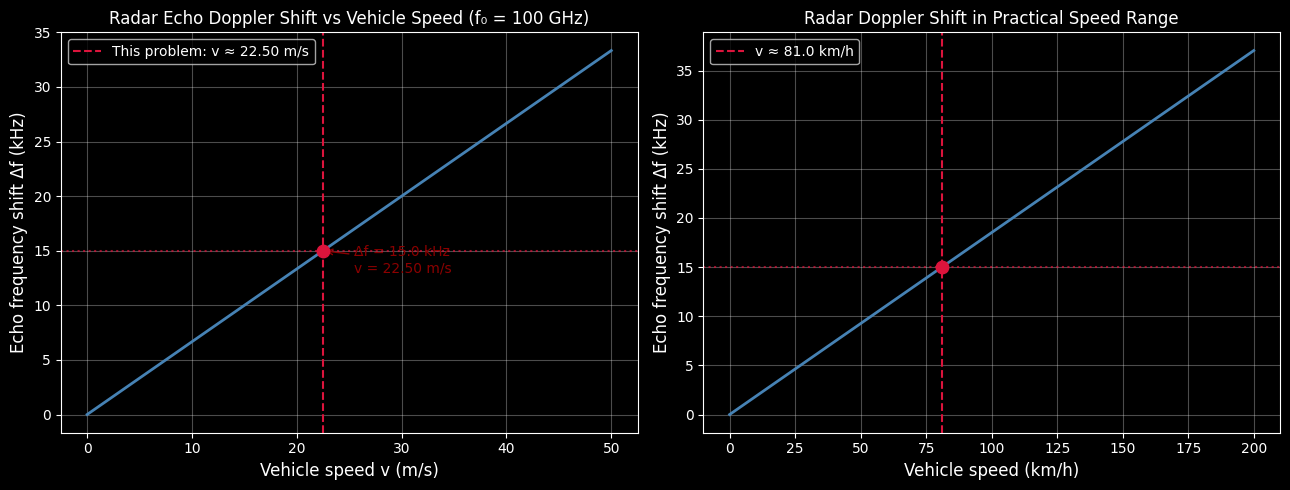

In [3]:
import numpy as np
import matplotlib.pyplot as plt

c  = 3.00e8
f0 = 100.0e9

v_range      = np.linspace(0, 50, 500)           # m/s
beta_range   = v_range / c
R_range      = (1 + beta_range) / (1 - beta_range)
delta_f_range = (R_range - 1) * f0               # Hz
delta_f_kHz   = delta_f_range / 1e3

v_star      = beta * c
delta_f_star = delta_f / 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Δf (kHz) vs speed (m/s)
axes[0].plot(v_range, delta_f_kHz, 'steelblue', linewidth=2)
axes[0].axvline(v_star, color='crimson', linestyle='--', label=f'This problem: v ≈ {v_star:.2f} m/s')
axes[0].axhline(delta_f_star, color='crimson', linestyle=':', alpha=0.7)
axes[0].scatter([v_star], [delta_f_star], color='crimson', zorder=5, s=80)
axes[0].annotate(f'Δf = {delta_f_star:.1f} kHz\nv = {v_star:.2f} m/s',
                 xy=(v_star, delta_f_star),
                 xytext=(v_star + 3, delta_f_star - 2),
                 fontsize=10, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'))
axes[0].set_xlabel('Vehicle speed v (m/s)', fontsize=12)
axes[0].set_ylabel('Echo frequency shift Δf (kHz)', fontsize=12)
axes[0].set_title('Radar Echo Doppler Shift vs Vehicle Speed (f₀ = 100 GHz)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: speed in km/h
v_kmh = np.linspace(0, 200, 1000)
v_ms  = v_kmh / 3.6
beta2 = v_ms / c
R2    = (1 + beta2) / (1 - beta2)
df2   = (R2 - 1) * f0 / 1e3   # kHz

axes[1].plot(v_kmh, df2, 'steelblue', linewidth=2)
v_star_kmh = v_star * 3.6
axes[1].axvline(v_star_kmh, color='crimson', linestyle='--',
                label=f'v ≈ {v_star_kmh:.1f} km/h')
axes[1].axhline(delta_f_star, color='crimson', linestyle=':', alpha=0.7)
axes[1].scatter([v_star_kmh], [delta_f_star], color='crimson', zorder=5, s=80)
axes[1].set_xlabel('Vehicle speed (km/h)', fontsize=12)
axes[1].set_ylabel('Echo frequency shift Δf (kHz)', fontsize=12)
axes[1].set_title('Radar Doppler Shift in Practical Speed Range', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

$$\boxed{v = \frac{R-1}{R+1}\,c \approx 7.50 \times 10^{-8} \times c \approx 22.5\,\text{m/s}}$$
